# Preprocessing

Here we select numeric features to conduct further analysis and remove outliers. Note that this stage does not normalize the data yet, which will be done *after* sampling process. 

DISCLAIMER: Outlier removal is based on https://www.kaggle.com/datasets/elemento/nyc-yellow-taxi-trip-data

In [43]:
import pandas as pd
import numpy as np
import time
import math
import os
import warnings
import datetime
from glob import glob
import seaborn as sns
import matplotlib.pylab as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.options.display.float_format = '{:.2f}'.format

In [44]:

DATA_ROOT = "./data/combined_parquet/"

print("Loading and combining parquet files...")
parquet_files = sorted(glob(f"{DATA_ROOT}part.*.parquet"))
df_list = [pd.read_parquet(file) for file in parquet_files]

Loading and combining parquet files...


In [45]:
main_taxi_df = pd.concat(df_list, ignore_index=True)
print(f"Combined dataset loaded. Total rows: {len(main_taxi_df)}")

Combined dataset loaded. Total rows: 12748829


In [46]:
ZONE_LOOKUP_PATH = './data/taxi_zone_lookup.csv'
lookup_df = pd.read_csv(ZONE_LOOKUP_PATH, keep_default_na=False)
lookup_df.columns = lookup_df.columns.str.strip()
id_to_borough_map = dict(zip(lookup_df['LocationID'], lookup_df['Borough']))
main_taxi_df['Borough'] = main_taxi_df['PULocationID'].map(id_to_borough_map).astype('category')
print(f"Borough labels are merged.\nDataset Info after merging:")
print(main_taxi_df.info())

Borough labels are merged.
Dataset Info after merging:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12748829 entries, 0 to 12748828
Data columns (total 12 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[ns]
 1   tpep_dropoff_datetime  datetime64[ns]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   pickup_longitude       float64       
 5   pickup_latitude        float64       
 6   dropoff_longitude      float64       
 7   dropoff_latitude       float64       
 8   total_amount           float64       
 9   PULocationID           float64       
 10  DOLocationID           float64       
 11  Borough                category      
dtypes: category(1), datetime64[ns](2), float64(9)
memory usage: 1.1 GB
None


In [47]:
print("Number of Samples per Borough")
borough_counts = main_taxi_df['Borough'].value_counts(dropna=False)
print(borough_counts)

Number of Samples per Borough
Borough
Manhattan        11613835
Queens             636903
Unknown            241572
Brooklyn           229982
Bronx                9663
N/A                  8183
NaN                  7810
EWR                   689
Staten Island         192
Name: count, dtype: int64


In [48]:
print("Total Zones per Borough")
original_borough_counts = lookup_df['Borough'].value_counts()
print(original_borough_counts)

Total Zones per Borough
Borough
Queens           69
Manhattan        69
Brooklyn         61
Bronx            43
Staten Island    20
EWR               1
Unknown           1
N/A               1
Name: count, dtype: int64


In [49]:
# check for coordinate outliers
outlier_locations_pickup = main_taxi_df[
    (main_taxi_df.pickup_longitude <= -74.15) | (main_taxi_df.pickup_latitude <= 40.5774) | 
    (main_taxi_df.pickup_longitude >= -73.7004) | (main_taxi_df.pickup_latitude >= 40.9176)
]
print("Number of Outlier Pick up Locations:", len(outlier_locations_pickup))

outlier_locations_dropoff = main_taxi_df[
    (main_taxi_df.dropoff_longitude <= -74.15) | (main_taxi_df.dropoff_latitude <= 40.5774) | 
    (main_taxi_df.dropoff_longitude >= -73.7004) | (main_taxi_df.dropoff_latitude >= 40.9176)
]
print("Number of Outlier Drop off Locations:", len(outlier_locations_dropoff))

Number of Outlier Pick up Locations: 247363
Number of Outlier Drop off Locations: 264068


In [50]:
# vectorized time and speed calculations
def return_with_trip_times(df):
    # keep required columns
    new_frame = df[[
        'passenger_count', 'trip_distance', 'pickup_longitude', 'pickup_latitude',
        'dropoff_longitude', 'dropoff_latitude', 'total_amount',
        'PULocationID', 'DOLocationID', 'Borough'
    ]].copy()

    # calculate durations in minutes using vectorized pandas operations
    time_diff = df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
    new_frame['trip_times'] = time_diff.dt.total_seconds() / 60.0
    
    # calculate Speed : avoiding division by zero by filling inf with NaN temporarily
    new_frame['Speed'] = 60 * (new_frame['trip_distance'] / new_frame['trip_times'])
    
    # cyclical time extraction: 
    # extract raw hour and day directly from the original datetime columns
    hour = df['tpep_pickup_datetime'].dt.hour
    day_of_week = df['tpep_pickup_datetime'].dt.dayofweek
    
    # map to sine/cosine : 24 hours in a day, 7 days in a week
    new_frame['hour_sin'] = np.sin(2 * np.pi * hour / 24.0)
    new_frame['hour_cos'] = np.cos(2 * np.pi * hour / 24.0)
    new_frame['day_sin'] = np.sin(2 * np.pi * day_of_week / 7.0)
    new_frame['day_cos'] = np.cos(2 * np.pi * day_of_week / 7.0)
    
    return new_frame
frame_with_durations = return_with_trip_times(main_taxi_df)

In [51]:
# outlier removal function
def remove_outliers(new_frame):
    a = new_frame.shape[0]
    print("\nNumber of pickup records:", a)

    temp_frame = new_frame[
        ((new_frame.dropoff_longitude >= -74.15) & (new_frame.dropoff_longitude <= -73.7004) &
         (new_frame.dropoff_latitude >= 40.5774) & (new_frame.dropoff_latitude <= 40.9176)) &
        ((new_frame.pickup_longitude >= -74.15) & (new_frame.pickup_latitude >= 40.5774) &
         (new_frame.pickup_longitude <= -73.7004) & (new_frame.pickup_latitude <= 40.9176))
    ]
    b = temp_frame.shape[0]
    print("Number of outlier coordinates lying outside NY boundaries:", (a-b))

    temp_frame = new_frame[(new_frame.trip_times > 0) & (new_frame.trip_times < 720)]
    c = temp_frame.shape[0]
    print("Number of outliers from trip times analysis:", (a-c))

    temp_frame = new_frame[(new_frame.trip_distance > 0) & (new_frame.trip_distance < 23)]
    d = temp_frame.shape[0]
    print("Number of outliers from trip distance analysis:", (a-d))

    temp_frame = new_frame[(new_frame.Speed <= 45.31) & (new_frame.Speed >= 0)]
    e = temp_frame.shape[0]
    print("Number of outliers from speed analysis:", (a-e))

    temp_frame = new_frame[(new_frame.total_amount < 1000) & (new_frame.total_amount > 0)]
    f = temp_frame.shape[0]
    print("Number of outliers from fare analysis:", (a-f))

    # apply all filters
    final_frame = new_frame[
        ((new_frame.dropoff_longitude >= -74.15) & (new_frame.dropoff_longitude <= -73.7004) &
         (new_frame.dropoff_latitude >= 40.5774) & (new_frame.dropoff_latitude <= 40.9176)) &
        ((new_frame.pickup_longitude >= -74.15) & (new_frame.pickup_latitude >= 40.5774) &
         (new_frame.pickup_longitude <= -73.7004) & (new_frame.pickup_latitude <= 40.9176)) &
        (new_frame.trip_times > 0) & (new_frame.trip_times < 720) &
        (new_frame.trip_distance > 0) & (new_frame.trip_distance < 23) &
        (new_frame.Speed < 45.31) & (new_frame.Speed > 0) &
        (new_frame.total_amount < 1000) & (new_frame.total_amount > 0)
    ]

    print("Total outliers removed:", a - final_frame.shape[0])
    return final_frame

In [52]:
# run the removal
print("\nRemoving outliers...")
frame_with_durations_outliers_removed = remove_outliers(frame_with_durations)
print(f"Rows after outlier removal: {len(frame_with_durations_outliers_removed):,}\n")


Removing outliers...

Number of pickup records: 12748829
Number of outlier coordinates lying outside NY boundaries: 293548
Number of outliers from trip times analysis: 23897
Number of outliers from trip distance analysis: 92225
Number of outliers from speed analysis: 36698
Number of outliers from fare analysis: 5275
Total outliers removed: 377541
Rows after outlier removal: 12,371,288



In [53]:
# drop invalid colms
frame_with_durations_outliers_removed = frame_with_durations_outliers_removed.dropna(subset=['PULocationID', 'DOLocationID', 'Borough'])
# converting location IDs to int
frame_with_durations_outliers_removed['PULocationID'] = frame_with_durations_outliers_removed['PULocationID'].astype('int64')
frame_with_durations_outliers_removed['DOLocationID'] = frame_with_durations_outliers_removed['DOLocationID'].astype('int64')

print(f"Rows after NA removal for PULocationID, DOLocationID and Borough: {len(frame_with_durations_outliers_removed):,}")

Rows after NA removal for PULocationID, DOLocationID and Borough: 12,369,560


In [54]:
boroughs_to_drop = ['N/A', 'Unknown', 'EWR']
frame_with_durations_outliers_removed = frame_with_durations_outliers_removed[~frame_with_durations_outliers_removed['Borough'].isin(boroughs_to_drop)]
frame_with_durations_outliers_removed['Borough'] = frame_with_durations_outliers_removed['Borough'].cat.remove_unused_categories()

print(f"Rows after N/A, Unknown, EWR Boroughs' removal: {len(frame_with_durations_outliers_removed):,}")

Rows after N/A, Unknown, EWR Boroughs' removal: 12,367,735


In [55]:
print("\n--- Final Borough Counts ---")
print(frame_with_durations_outliers_removed['Borough'].value_counts())


--- Final Borough Counts ---
Borough
Manhattan        11526847
Queens             606540
Brooklyn           225492
Bronx                8777
Staten Island          79
Name: count, dtype: int64


In [56]:
frame_with_durations_outliers_removed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12367735 entries, 0 to 12748828
Data columns (total 16 columns):
 #   Column             Dtype   
---  ------             -----   
 0   passenger_count    float64 
 1   trip_distance      float64 
 2   pickup_longitude   float64 
 3   pickup_latitude    float64 
 4   dropoff_longitude  float64 
 5   dropoff_latitude   float64 
 6   total_amount       float64 
 7   PULocationID       int64   
 8   DOLocationID       int64   
 9   Borough            category
 10  trip_times         float64 
 11  Speed              float64 
 12  hour_sin           float64 
 13  hour_cos           float64 
 14  day_sin            float64 
 15  day_cos            float64 
dtypes: category(1), float64(13), int64(2)
memory usage: 1.5 GB


In [57]:
# initial stats:
df_stat_initial= frame_with_durations_outliers_removed.drop(columns=['Borough','DOLocationID', 'PULocationID'], errors='ignore')
stats_functions = ['min', 'max', 'mean', 'std', 'var', 'skew', 'kurt', 'median']
stats_initial = df_stat_initial.agg(stats_functions).T
stats_initial = stats_initial.round(2)
print("Initial Statistics")
print(stats_initial)

Initial Statistics
                     min    max   mean   std    var  skew   kurt  median
passenger_count     0.00   9.00   1.69  1.35   1.81  2.07   3.12    1.00
trip_distance       0.01  22.99   2.74  3.20  10.22  3.04  10.67    1.69
pickup_longitude  -74.15 -73.70 -73.97  0.03   0.00  3.50  15.25  -73.98
pickup_latitude    40.58  40.91  40.75  0.03   0.00 -1.04   3.37   40.75
dropoff_longitude -74.15 -73.70 -73.97  0.03   0.00  3.04  14.27  -73.98
dropoff_latitude   40.58  40.92  40.75  0.03   0.00 -0.47   3.04   40.75
total_amount        0.01 900.30  14.51 11.04 121.83  3.24  37.32   11.16
trip_times          0.02 719.77  12.33 10.26 105.19 12.89 614.60    9.98
Speed               0.00  45.31  12.41  6.11  37.31  1.64   3.70   11.06
hour_sin           -1.00   1.00  -0.21  0.67   0.45  0.44  -1.21   -0.26
hour_cos           -1.00   1.00  -0.09  0.71   0.50  0.20  -1.46   -0.26
day_sin            -0.97   0.97  -0.07  0.71   0.51  0.12  -1.49    0.00
day_cos            -0.90   1.00 

In [58]:
# apply log transform to skewed features
print("Applying log transformations to highly skewed features: trip_times, trip_distance, total_amount")
frame_with_durations_outliers_removed['log_trip_times'] = np.log(frame_with_durations_outliers_removed['trip_times'])
frame_with_durations_outliers_removed['log_trip_distance'] = np.log(frame_with_durations_outliers_removed['trip_distance'])
frame_with_durations_outliers_removed['log_total_amount'] = np.log(frame_with_durations_outliers_removed['total_amount'])

Applying log transformations to highly skewed features: trip_times, trip_distance, total_amount


In [59]:
df_stat_final= frame_with_durations_outliers_removed.drop(columns=['Borough','DOLocationID', 'PULocationID'], errors='ignore')
stats_final = df_stat_final.agg(stats_functions).T
stats_final = stats_final.round(2)
print("Final Statistics")
print(stats_final)

Final Statistics
                     min    max   mean   std    var  skew   kurt  median
passenger_count     0.00   9.00   1.69  1.35   1.81  2.07   3.12    1.00
trip_distance       0.01  22.99   2.74  3.20  10.22  3.04  10.67    1.69
pickup_longitude  -74.15 -73.70 -73.97  0.03   0.00  3.50  15.25  -73.98
pickup_latitude    40.58  40.91  40.75  0.03   0.00 -1.04   3.37   40.75
dropoff_longitude -74.15 -73.70 -73.97  0.03   0.00  3.04  14.27  -73.98
dropoff_latitude   40.58  40.92  40.75  0.03   0.00 -0.47   3.04   40.75
total_amount        0.01 900.30  14.51 11.04 121.83  3.24  37.32   11.16
trip_times          0.02 719.77  12.33 10.26 105.19 12.89 614.60    9.98
Speed               0.00  45.31  12.41  6.11  37.31  1.64   3.70   11.06
hour_sin           -1.00   1.00  -0.21  0.67   0.45  0.44  -1.21   -0.26
hour_cos           -1.00   1.00  -0.09  0.71   0.50  0.20  -1.46   -0.26
day_sin            -0.97   0.97  -0.07  0.71   0.51  0.12  -1.49    0.00
day_cos            -0.90   1.00  -

C:\Users\USER\AppData\Local\Temp\ipykernel_18792\3999534347.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(ltt_sample, hist=True, kde=True)


<Axes: xlabel='trip_times', ylabel='Density'>

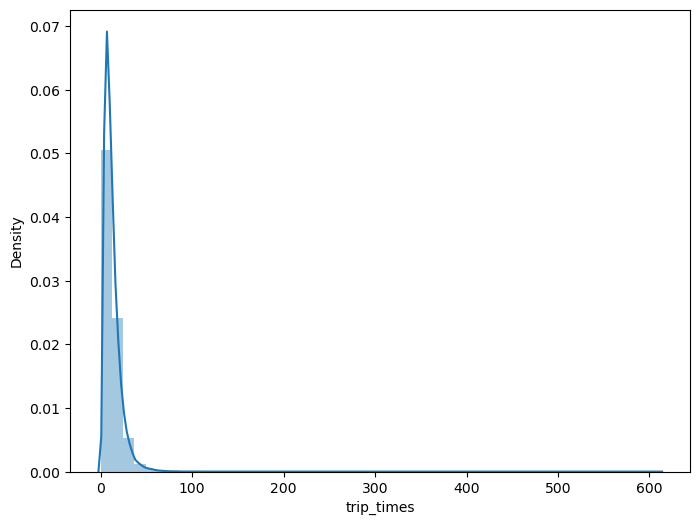

In [65]:
# PDF of values of trip-times
ltt_sample = frame_with_durations_outliers_removed['trip_times'].sample(n = 200000)

plt.figure(figsize = (8, 6))
sns.distplot(ltt_sample, hist=True, kde=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_18792\3013371376.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(ltt_sample, hist=True, kde=True)


<Axes: xlabel='log_trip_times', ylabel='Density'>

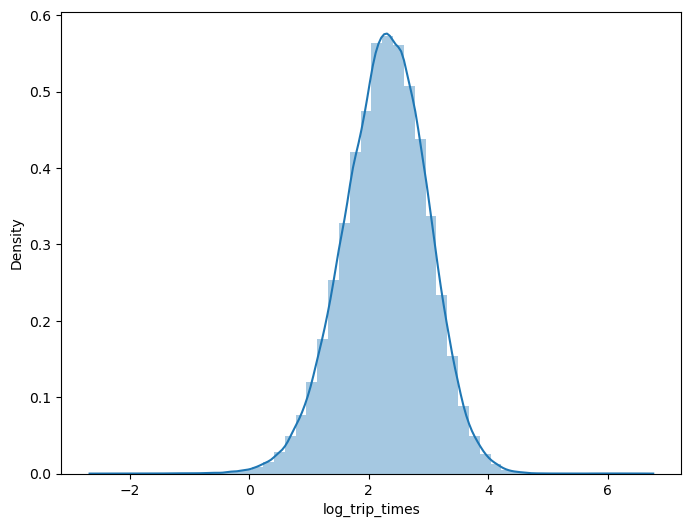

In [61]:
# PDF of log-values of trip-times
ltt_sample = frame_with_durations_outliers_removed['log_trip_times'].sample(n = 200000)

plt.figure(figsize = (8, 6))
sns.distplot(ltt_sample, hist=True, kde=True)

In [38]:
# drop raw colmns for transformed data and reset the index
frame_to_export = frame_with_durations_outliers_removed.drop(columns=['trip_times','total_amount','trip_distance'], errors='ignore')
frame_to_export = frame_to_export.reset_index(drop=True)

frame_to_export.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12367735 entries, 0 to 12367734
Data columns (total 16 columns):
 #   Column             Dtype   
---  ------             -----   
 0   passenger_count    float64 
 1   pickup_longitude   float64 
 2   pickup_latitude    float64 
 3   dropoff_longitude  float64 
 4   dropoff_latitude   float64 
 5   PULocationID       int64   
 6   DOLocationID       int64   
 7   Borough            category
 8   Speed              float64 
 9   hour_sin           float64 
 10  hour_cos           float64 
 11  day_sin            float64 
 12  day_cos            float64 
 13  log_trip_times     float64 
 14  log_trip_distance  float64 
 15  log_total_amount   float64 
dtypes: category(1), float64(13), int64(2)
memory usage: 1.4 GB


In [39]:
# export to parquet
num_partitions = 31

total_rows = len(frame_to_export)
chunk_size = int(np.ceil(total_rows / num_partitions))

print(f"Exporting {total_rows} rows into {num_partitions} files...")
print(f"Targeting ~{chunk_size} rows per file.\n")

output_dir = './data/cleaned_partitions/'
os.makedirs(output_dir, exist_ok=True)

for i in range(num_partitions):
    start_idx = i * chunk_size
    
    if i == num_partitions - 1:
        end_idx = total_rows
    else:
        end_idx = (i + 1) * chunk_size
        
    chunk = frame_to_export.iloc[start_idx:end_idx]
    file_name = f"{output_dir}cleaned_part{i}.parquet"
    chunk.to_parquet(file_name, index=False)
    
    print(f"Saved {file_name} (Rows: {len(chunk)})")

print(f"\nSuccessfully exported all {num_partitions} files!")

Exporting 12367735 rows into 31 files...
Targeting ~398960 rows per file.

Saved ./data/cleaned_partitions/cleaned_part0.parquet (Rows: 398960)
Saved ./data/cleaned_partitions/cleaned_part1.parquet (Rows: 398960)
Saved ./data/cleaned_partitions/cleaned_part2.parquet (Rows: 398960)
Saved ./data/cleaned_partitions/cleaned_part3.parquet (Rows: 398960)
Saved ./data/cleaned_partitions/cleaned_part4.parquet (Rows: 398960)
Saved ./data/cleaned_partitions/cleaned_part5.parquet (Rows: 398960)
Saved ./data/cleaned_partitions/cleaned_part6.parquet (Rows: 398960)
Saved ./data/cleaned_partitions/cleaned_part7.parquet (Rows: 398960)
Saved ./data/cleaned_partitions/cleaned_part8.parquet (Rows: 398960)
Saved ./data/cleaned_partitions/cleaned_part9.parquet (Rows: 398960)
Saved ./data/cleaned_partitions/cleaned_part10.parquet (Rows: 398960)
Saved ./data/cleaned_partitions/cleaned_part11.parquet (Rows: 398960)
Saved ./data/cleaned_partitions/cleaned_part12.parquet (Rows: 398960)
Saved ./data/cleaned_part